# 🟦 Celda 1 — Importación de librerías

In [1]:
# ============================================
# 🧩 01. Importación de librerías
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


# 🟦 Celda 2 — Carga de datos procesados

In [3]:
# ============================================
# 📥 02. Carga de datos procesados
# ============================================

# Cargamos los datos codificados desde el notebook anterior
X = pd.read_csv("../data/processed/X_encoded.csv")
y = pd.read_csv("../data/processed/y.csv").squeeze()

print("✅ Datos cargados correctamente.")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


✅ Datos cargados correctamente.
Features shape: (8124, 116)
Target shape: (8124,)


#  🟦 Celda 3 — Aplicar PCA (reducción de dimensionalidad)

In [4]:
# ============================================
# 🧠 03. Reducción de dimensionalidad con PCA
# ============================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

# Creamos un DataFrame con las componentes
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df['class'] = y
X_pca_df.head()


Varianza explicada por las 2 componentes: 30.70%


,PC1,PC2,class
0,0.996245,-0.946892,p
1,1.441733,-0.164154,e
2,1.524085,-0.408746,e
3,1.151800,-0.675820,p
4,0.617503,-0.996143,e


# 🟦 Celda 4 — Visualización del PCA

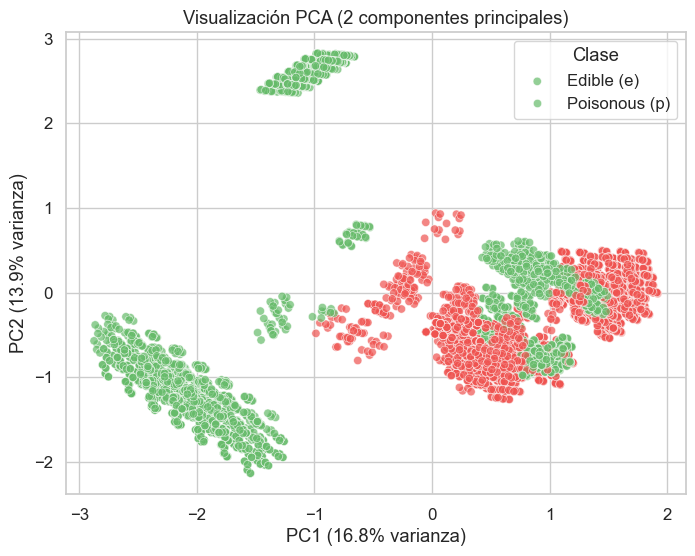

In [5]:
# ============================================
# 🎨 04. Visualización de PCA
# ============================================

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='PC1', y='PC2', hue='class', palette=['#66bb6a', '#ef5350'], alpha=0.7)
plt.title("Visualización PCA (2 componentes principales)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.legend(title="Clase", labels=["Edible (e)", "Poisonous (p)"])
plt.show()


# 🟦 Celda 5 — Determinar número óptimo de clusters (Método del codo)

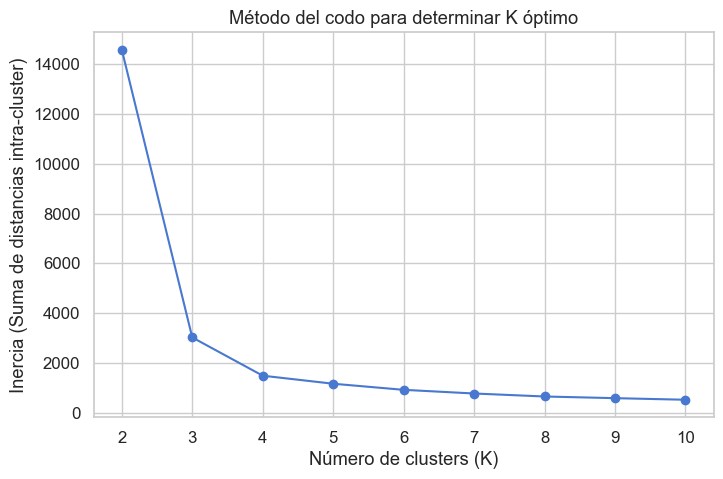

In [6]:
# ============================================
# 📉 05. Determinación del número óptimo de clusters (método del codo)
# ============================================

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Método del codo para determinar K óptimo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (Suma de distancias intra-cluster)")
plt.show()


# 🟦 Celda 6 — Aplicar K-Means con el K óptimo

In [7]:
# ============================================
# 🤖 06. Aplicación de K-Means con K óptimo
# ============================================

# Según el gráfico, el punto de inflexión suele estar en K=2 (coherente con 2 clases)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

X_pca_df['cluster'] = clusters
X_pca_df.head()


,PC1,PC2,class,cluster
0,0.996245,-0.946892,p,0
1,1.441733,-0.164154,e,0
2,1.524085,-0.408746,e,0
3,1.151800,-0.675820,p,0
4,0.617503,-0.996143,e,0


# 🟦 Celda 7 — Visualización de Clusters

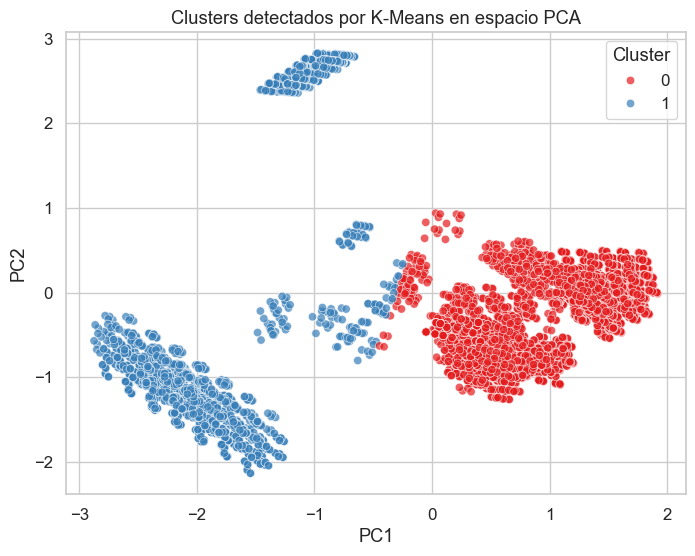

In [8]:
# ============================================
# 🎯 07. Visualización de clusters
# ============================================

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='PC1', y='PC2', hue='cluster', palette='Set1', alpha=0.7)
plt.title("Clusters detectados por K-Means en espacio PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


# 🟦 Celda 8 — Comparación de clusters vs clases reales

In [9]:
# ============================================
# 🔍 08. Evaluación de correspondencia con clases reales
# ============================================

# Métricas de similitud
ari = adjusted_rand_score(y.map({'e': 0, 'p': 1}), clusters)
silhouette = silhouette_score(X_pca, clusters)

print(f"🔹 Adjusted Rand Index (similaridad con clases reales): {ari:.3f}")
print(f"🔹 Silhouette Score (cohesión del clustering): {silhouette:.3f}")


🔹 Adjusted Rand Index (similaridad con clases reales): 0.606
🔹 Silhouette Score (cohesión del clustering): 0.584


# 🟦 Celda 9 — Guardado de resultados

In [10]:
# ============================================
# 💾 09. Guardado de resultados
# ============================================

import os
os.makedirs("../data/results", exist_ok=True)

X_pca_df.to_csv("../data/results/pca_kmeans_results.csv", index=False)
print("✅ Resultados guardados en data/results/pca_kmeans_results.csv")


✅ Resultados guardados en data/results/pca_kmeans_results.csv
